In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 2.0.2
pandas 2.2.2
sklearn 1.6.1
torch 2.9.0+cu126
cuda:0


# 数据预处理

In [2]:
# 加载FashionMNIST数据集
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL图像或numpy数组转换为tensor,ToTensor会自动将图像转换为tensor，并归一化到[0,1]范围
    # transforms.Normalize((0.5,), (0.5,))  # 标准化到[-1, 1]范围
])

# 下载并加载训练集
train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据存储路径
    train=True,     # 加载训练集
    download=True,  # 如果数据不存在则下载
    transform=transform
)

# 下载并加载测试集
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,    # 加载测试集
    download=True,
    transform=transform
)

# 打印数据集信息
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"训练集数据类型: {type(train_dataset)}")
print(f"单个dataset元素类型: {type(train_dataset[0])}")
print(f"单个dataset元素是什么: {train_dataset[0]}")
print(f"图像尺寸: {train_dataset[0][0].shape}")
# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
# FashionMNIST类别标签
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]


训练集大小: 60000
测试集大小: 10000
训练集数据类型: <class 'torchvision.datasets.mnist.FashionMNIST'>
单个dataset元素类型: <class 'tuple'>
单个dataset元素是什么: (tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [3]:
print(train_dataset.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


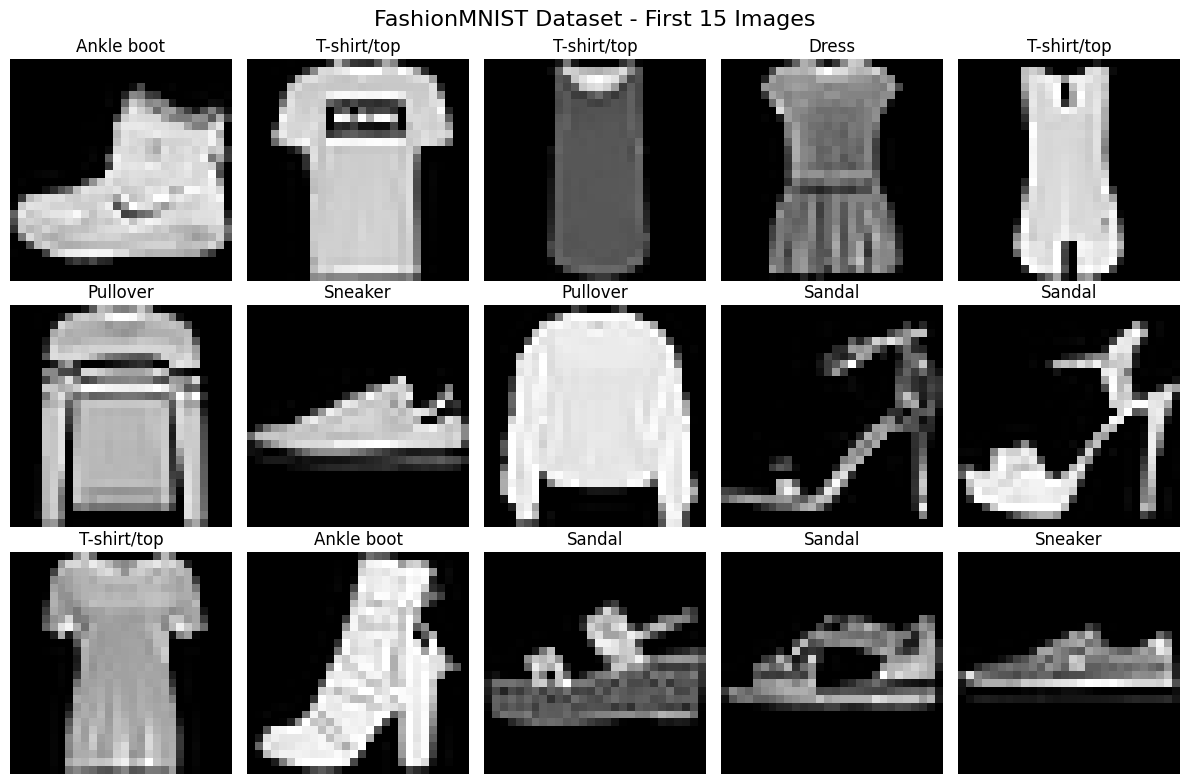

In [4]:
import matplotlib.pyplot as plt

# 显示前15张图片，每行5张，共3行
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
fig.suptitle('FashionMNIST Dataset - First 15 Images', fontsize=16)

for i in range(15):
    row = i // 5
    col = i % 5

    # 获取图像和标签
    image, label = train_dataset[i]

    # 将tensor转换为numpy数组并去掉通道维度
    image_np = image.squeeze().numpy()

    # 显示图像
    axes[row, col].imshow(image_np, cmap='gray')
    axes[row, col].set_title(f'{class_names[label]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [5]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
train_iter = iter(train_loader)
batch_images, batch_labels = next(train_iter)
print(f"批次图像张量形状: {batch_images.shape}")
print(f"批次标签张量形状: {batch_labels.shape}")
print(batch_labels)

训练集DataLoader批次数: 1875
测试集DataLoader批次数: 313
每个批次大小: 32
批次图像张量形状: torch.Size([32, 1, 28, 28])
批次标签张量形状: torch.Size([32])
tensor([8, 9, 9, 0, 2, 7, 0, 9, 1, 7, 7, 8, 0, 0, 9, 2, 1, 5, 3, 9, 4, 6, 0, 3,
        3, 9, 2, 4, 5, 0, 7, 3])


In [6]:
28*28

784

在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。

# 搭建模型

In [14]:
import torch.nn as nn
import torchvision.transforms as transforms



class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # 输入 (batch, 1, 28, 28)
        self.normalize = transforms.Normalize(mean=[0.2860], std=[0.3530])  # 增加Normalize操作(在forward里用)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # (batch, 32, 28, 28)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)  # (batch, 32, 28, 28)
        self.pool = nn.MaxPool2d(2, 2)                           # (batch, 32, 14, 14)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (batch, 64, 14, 14)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # (batch, 64, 14, 14)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (batch, 128, 7, 7)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1) # (batch, 128, 7, 7)

        self.selu = nn.SELU(inplace=True)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # 在最开始加入归一化
        x = self.normalize(x)
        x = self.selu(self.conv1(x))
        x = self.selu(self.conv2(x))
        x = self.pool(x)

        x = self.selu(self.conv3(x))
        x = self.selu(self.conv4(x))
        x = self.pool(x)

        x = self.selu(self.conv5(x))
        x = self.selu(self.conv6(x))
        x = self.pool(x)

        x = self.flatten(x)
        x = self.selu(self.fc1(x))
        x = self.fc2(x)
        return x

# 实例化模型
model = FashionCNN()


In [15]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 1, 28, 28)  # batch_size=1, channels=1, height=28, width=28
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [16]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
conv1.weight: 288
conv1.bias: 32
conv2.weight: 9216
conv2.bias: 32
conv3.weight: 18432
conv3.bias: 64
conv4.weight: 36864
conv4.bias: 64
conv5.weight: 73728
conv5.bias: 128
conv6.weight: 147456
conv6.bias: 128
fc1.weight: 147456
fc1.bias: 128
fc2.weight: 1280
fc2.bias: 10
模型总参数量: 435306


In [17]:
32*3*3*64

18432

# 训练

In [18]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [19]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
# 加入早停，patience设为3，val_loss无提升3次后停止
early_stopping = wangdao_train.EarlyStopping(patience=5, min_delta=0.001,mode='max')

trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500,
    early_stopping=early_stopping
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 500] Val Loss: 0.3868 Val Acc: 0.8586
[Step 1000] Val Loss: 0.4149 Val Acc: 0.8505
[Step 1500] Val Loss: 0.3462 Val Acc: 0.8691
Epoch [1/20]  Train Loss: 0.4039  Train Acc: 0.8532
[Step 2000] Val Loss: 0.3465 Val Acc: 0.8706
[Step 2500] Val Loss: 0.3102 Val Acc: 0.8890
[Step 3000] Val Loss: 0.3404 Val Acc: 0.8818
[Step 3500] Val Loss: 0.3484 Val Acc: 0.8701
Epoch [2/20]  Train Loss: 0.2939  Train Acc: 0.8936
[Step 4000] Val Loss: 0.3267 Val Acc: 0.8918
[Step 4500] Val Loss: 0.3518 Val Acc: 0.8804
[Step 5000] Val Loss: 0.2813 Val Acc: 0.9026
[Step 5500] Val Loss: 0.2802 Val Acc: 0.8986
Epoch [3/20]  Train Loss: 0.2633  Train Acc: 0.9048
[Step 6000] Val Loss: 0.3022 Val Acc: 0.8984
[Step 6500] Val Loss: 0.3374 Val Acc: 0.8871
[Step 7000] Val Loss: 0.2921 Val Acc: 0.9001
[Step 7500] Val Loss: 0.2846 Val Acc: 0.9018
Early stopping triggered at step 7500.


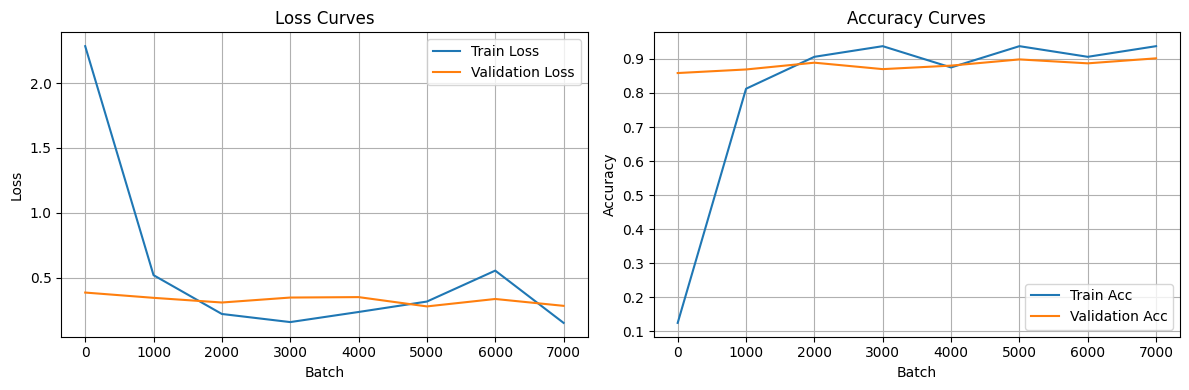

In [20]:
trainer.plot_curves()
